<a href="https://colab.research.google.com/github/adilsher-dev/DEEP-LEARNING/blob/main/CNN_AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers


(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0


x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [ ]:

encoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Conv2D(
        64, (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Flatten(),

    layers.Dense(64, activation='relu')
])

encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,584 (857.75 KB)

 Trainable params: 219,584 (857.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

decoder = models.Sequential([
    layers.Input(shape=(64,)),

    layers.Dense(7 * 7 * 64, activation='relu'),

    layers.Reshape((7, 7, 64)),

    layers.Conv2DTranspose(
        64, (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Conv2DTranspose(
        32, (3, 3),
        activation='relu',
        strides=2,
        padding='same'
    ),

    layers.Conv2DTranspose(
        1, (3, 3),
        activation='sigmoid',
        padding='same'
    )
])

decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,521 (1013.75 KB)

 Trainable params: 259,521 (1013.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

autoencoder = models.Sequential([
    encoder,
    decoder
])

autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64)             │       219,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       259,521 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,105 (1.83 MB)

 Trainable params: 479,105 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [ ]:

history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 193ms/step - loss: 0.1585 - val_loss: 0.0864
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 183ms/step - loss: 0.0808 - val_loss: 0.0761
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 185ms/step - loss: 0.0749 - val_loss: 0.0726
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 188ms/step - loss: 0.0723 - val_loss: 0.0707
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 186ms/step - loss: 0.0708 - val_loss: 0.0699
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 188ms/step - loss: 0.0697 - val_loss: 0.0690
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 187ms/step - loss: 0.0690 - val_loss: 0.0682
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 189ms/step - loss: 0.0685 - val_loss: 0.0680
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 183ms/step - loss: 0.0680 - val_loss: 0.0675
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 186ms/step - loss: 0.0677 - val_loss: 0.0673


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


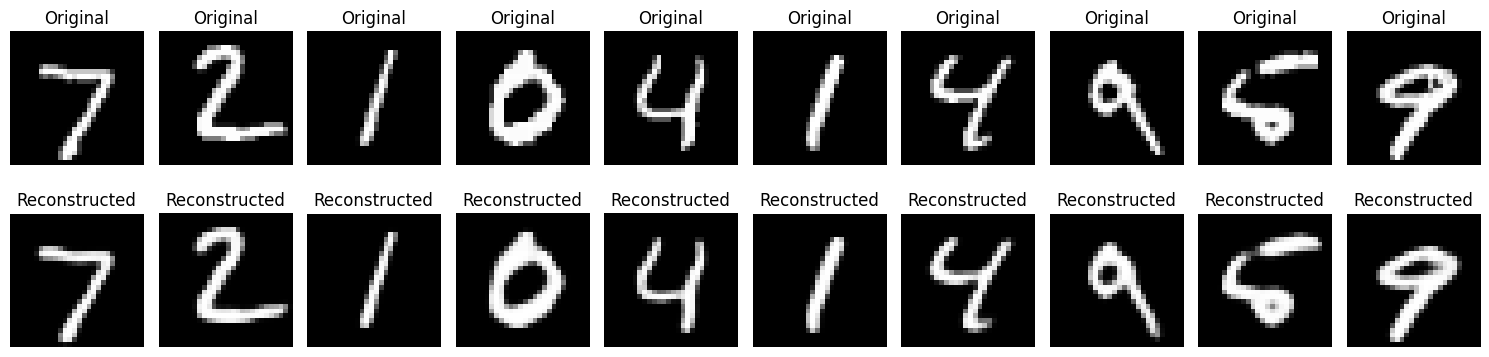

In [ ]:


decoded_images = autoencoder.predict(x_test)


n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()